# Анализ сайта СберАвтоподписка
**Цель:** построить модель, предсказывающую вероятность целевого действия пользователя на сайте (заявка, звонок и тд.).

**Данные:** Google Analytics — сессии (ga_sessions) и события (ga_hits) за май–декабрь 2021 года.

**Метрика качества:** ROC-AUC ≥ 0.65

## 1. Подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PATH = r'C:\Users\Никита\Skillfactory\Project workshop (hackathon)\df_target.csv'
df = pd.read_csv(PATH, low_memory=False)
df['visit_date'] = pd.to_datetime(df['visit_date'])
print('Размер датасета:', df.shape)
df.head(3)

Размер датасета: (1860042, 19)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0


In [2]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info)

                                   dtype    nulls  null_%   unique
session_id                        object        0    0.00  1860042
client_id                         object        0    0.00  1391719
visit_date                datetime64[ns]        0    0.00      226
visit_time                        object        0    0.00    85318
visit_number                       int64        0    0.00      537
utm_source                        object       97    0.01      293
utm_medium                        object        0    0.00       56
utm_campaign                      object   219603   11.81      412
utm_adcontent                     object   335615   18.04      286
utm_keyword                       object  1082061   58.17     1219
device_category                   object        0    0.00        3
device_os                         object  1070138   57.53       13
device_brand                      object   367178   19.74      205
device_model                      object  1843704   99.12     

**Пропуски:**
- `utm_keyword` — 58% пропусков: ключевые слова часто не передаются в рекламных кампаниях
- `device_os` — 57% пропусков: у десктопных браузеров ОС часто не определяется
- `device_model` — 99% пропусков: столбец практически пуст, удалим его
- `device_brand` — 20% пропусков


In [3]:
# Заполняем пропуски, удаляем бесполезный столбец и проверяем дубликаты
cat_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_keyword',
            'device_os', 'device_brand', 'device_model']
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

df.drop(columns=['device_model'], inplace=True)

dups = df.duplicated(subset='session_id').sum()
print(f'Дубликатов по session_id: {dups}')
if dups > 0:
    df.drop_duplicates(subset='session_id', inplace=True)

print(f'Датасет после очистки: {df.shape}')

Дубликатов по session_id: 0
Датасет после очистки: (1860042, 18)


## 2. Разведочный анализ (EDA)

Распределение целевой переменной:
target
0    1843320
1      16722
Name: count, dtype: int64

Доля целевых сессий: 0.90%


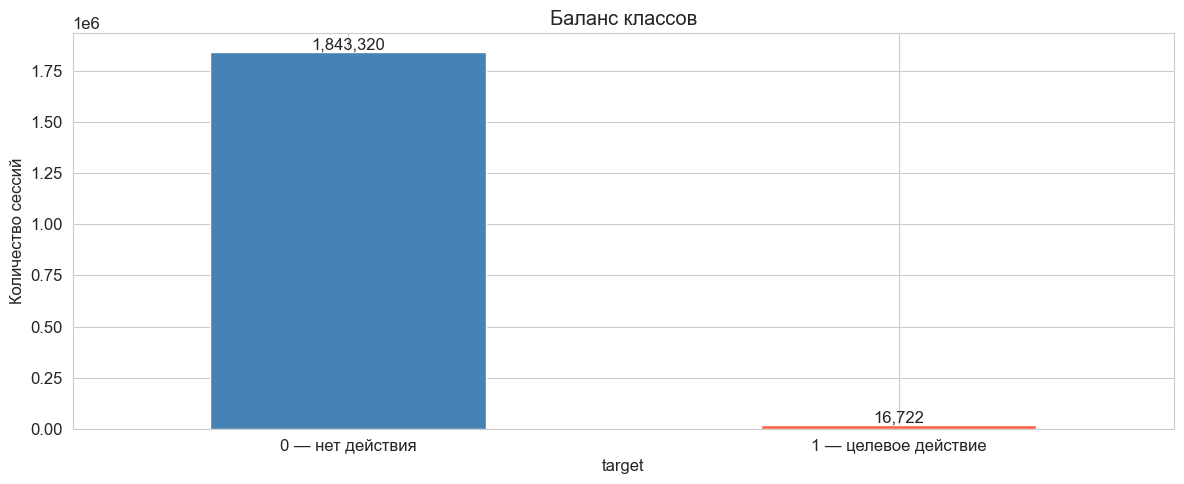

In [4]:
# Баланс классов
print('Распределение целевой переменной:')
print(df['target'].value_counts())
print(f"\nДоля целевых сессий: {df['target'].mean()*100:.2f}%")

fig, ax = plt.subplots()
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Баланс классов')
ax.set_xlabel('target')
ax.set_ylabel('Количество сессий')
ax.set_xticklabels(['0 — нет действия', '1 — целевое действие'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Вывод:** классы сильно несбалансированы — только 0.90% сессий содержат целевое действие. При обучении моделей необходимо учитывать дисбаланс через `class_weight='balanced'` ил `scale_pos_weight`.

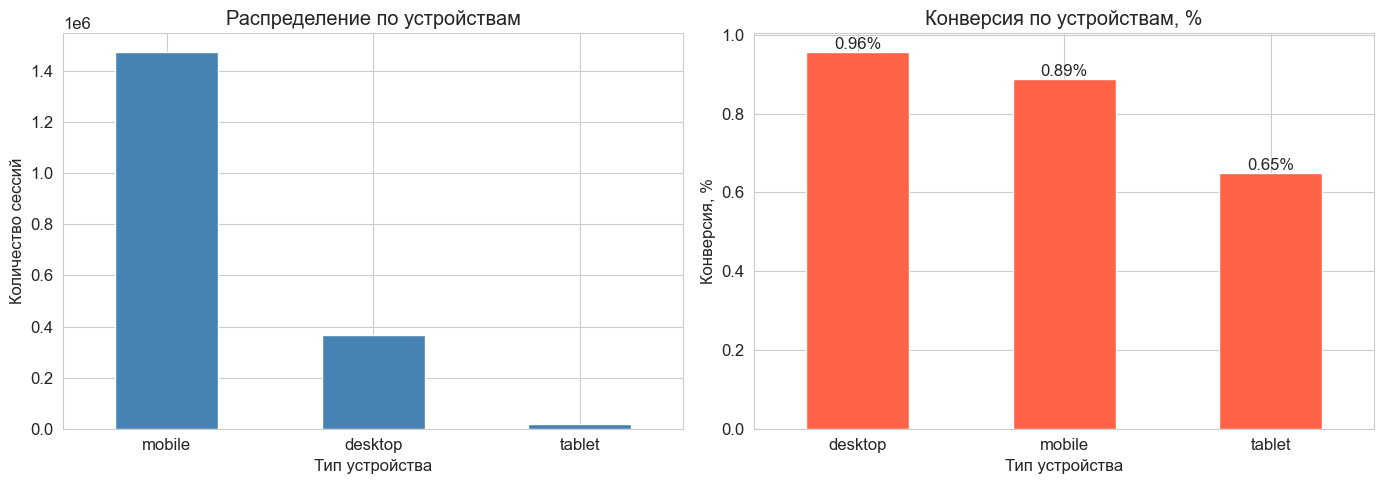

In [5]:
# Конверсия по устройствам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['device_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение по устройствам')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Количество сессий')
axes[0].tick_params(axis='x', rotation=0)

conv_by_device = df.groupby('device_category')['target'].mean() * 100
conv_by_device.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по устройствам, %')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Конверсия, %')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Вывод:** мобильные устройства создают ~80% трафика, однако десктоп конвертирует лучше (0.96% против 0.89%). Это объясняется тем, что на десктопе удобнее заполнять формы. Тип устройства будет полезным признаком для модели

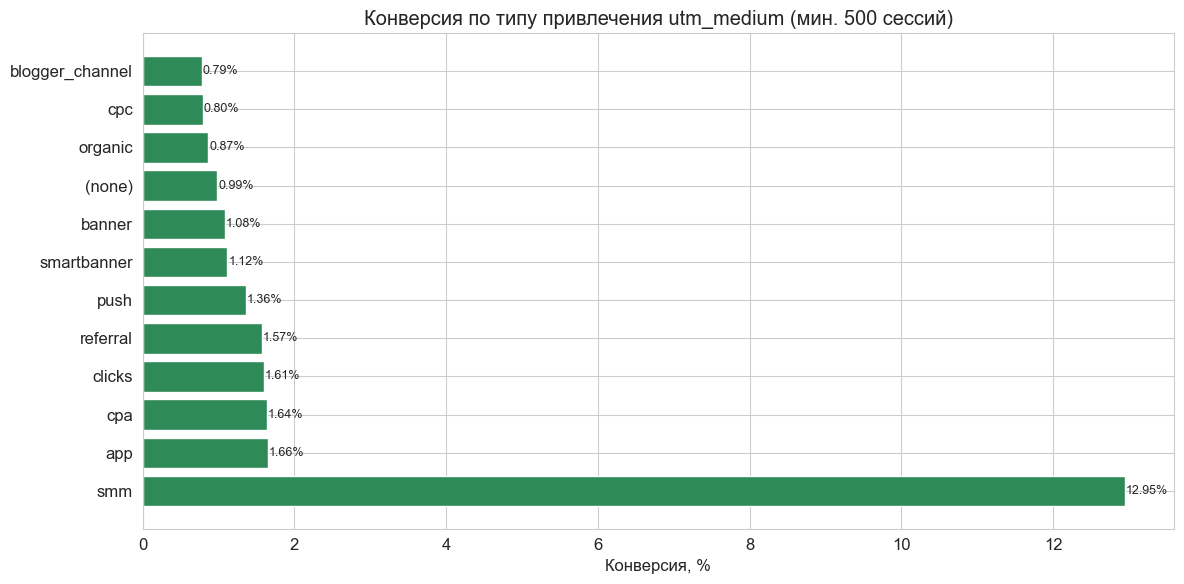

In [6]:
# Конверсия по utm_medium
medium_stats = (
    df.groupby('utm_medium')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
    .query('sessions >= 500')
    .sort_values('conv_rate', ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(medium_stats.index, medium_stats['conv_rate'], color='seagreen')
ax.set_title('Конверсия по типу привлечения utm_medium (мин. 500 сессий)')
ax.set_xlabel('Конверсия, %')
for bar, val in zip(bars, medium_stats['conv_rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Вывод:** канал `smm` (соцсети) конвертирует исключительно высоко — 12.95%, что в несколько раз выше остальных. Каналы `cpa` (1.64%) и `app` (1.66%) также показывают хорошие результаты — платная аудитория с оплатой за действие. Контекстная реклама `cpc` (0.80%) конвертирует хуже всего.


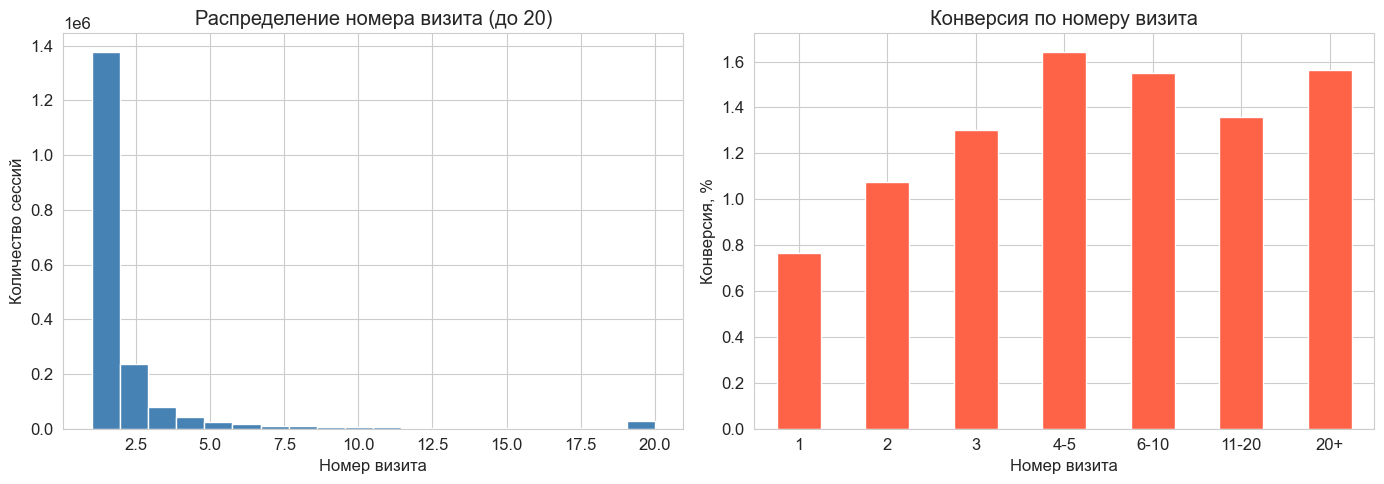

In [7]:
# Конверсия по номеру визита
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['visit_number'].clip(upper=20).hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Распределение номера визита (до 20)')
axes[0].set_xlabel('Номер визита')
axes[0].set_ylabel('Количество сессий')

visit_conv = (
    df.assign(visit_bucket=pd.cut(df['visit_number'], bins=[0,1,2,3,5,10,20,1000],
                                   labels=['1','2','3','4-5','6-10','11-20','20+']))
    .groupby('visit_bucket', observed=True)['target']
    .mean() * 100
)
visit_conv.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по номеру визита')
axes[1].set_xlabel('Номер визита')
axes[1].set_ylabel('Конверсия, %')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Вывод:** конверсия растёт с каждым повторным визитом и достигает пика на 4-5 посещении (1.64%). Пользователи, посещающие сайт повторно, конвертируют в 2 раза лучше первичных (0.75%). Признак `visit_number` будет одним из ключевых в модели.

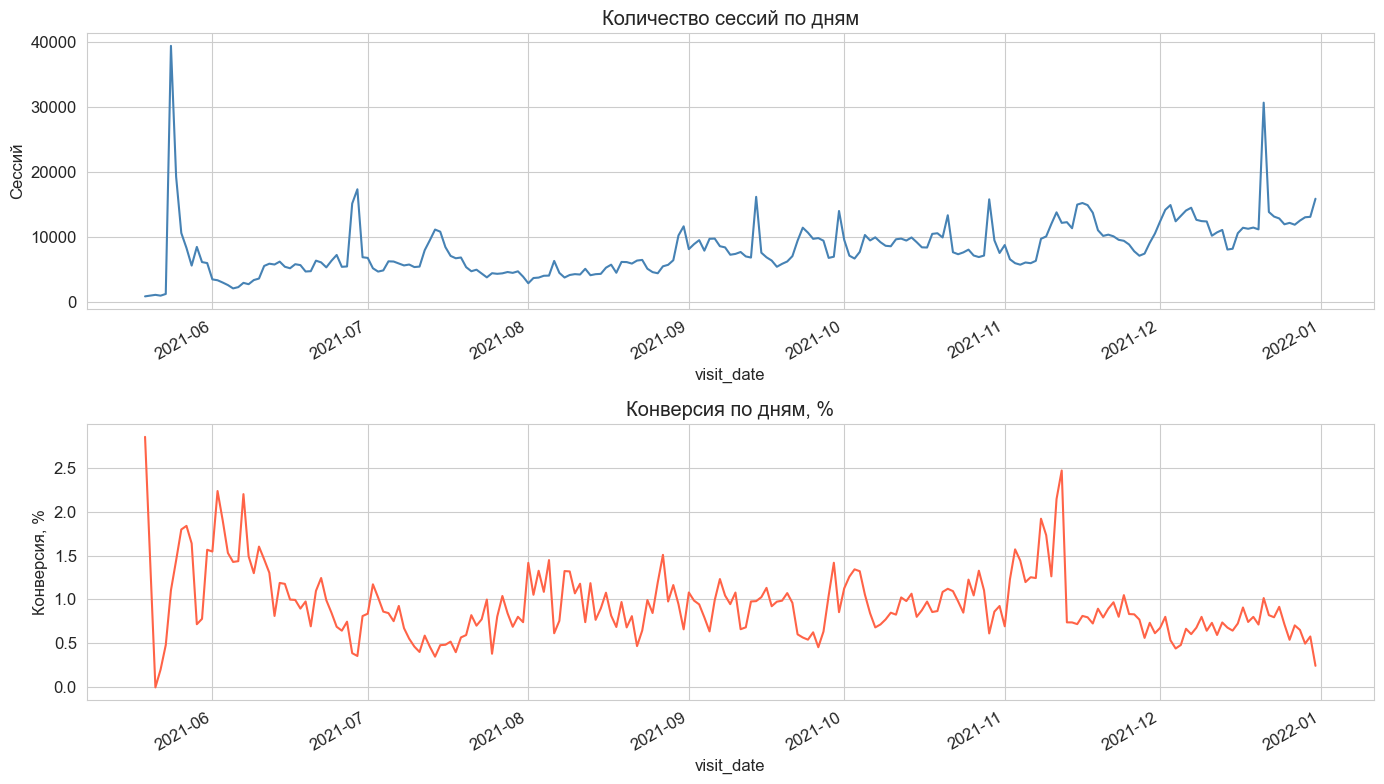

In [8]:
# Динамика по дням
daily = (
    df.groupby('visit_date')
    .agg(sessions=('target', 'count'), conversions=('target', 'sum'))
    .assign(conv_rate=lambda x: x['conversions'] / x['sessions'] * 100)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
daily['sessions'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Количество сессий по дням')
axes[0].set_ylabel('Сессий')

daily['conv_rate'].plot(ax=axes[1], color='tomato')
axes[1].set_title('Конверсия по дням, %')
axes[1].set_ylabel('Конверсия, %')
plt.tight_layout()
plt.show()

**Вывод:** трафик рос с мая по декабрь 2021 года с пиками в июн и декабре — следствие рекламных кампаний. Конверсия в начале периода была выше - ранние пользователи более мотивированы. Ноябрь выделяется пиком конверсии. Признак `month` будет полезен в модели.

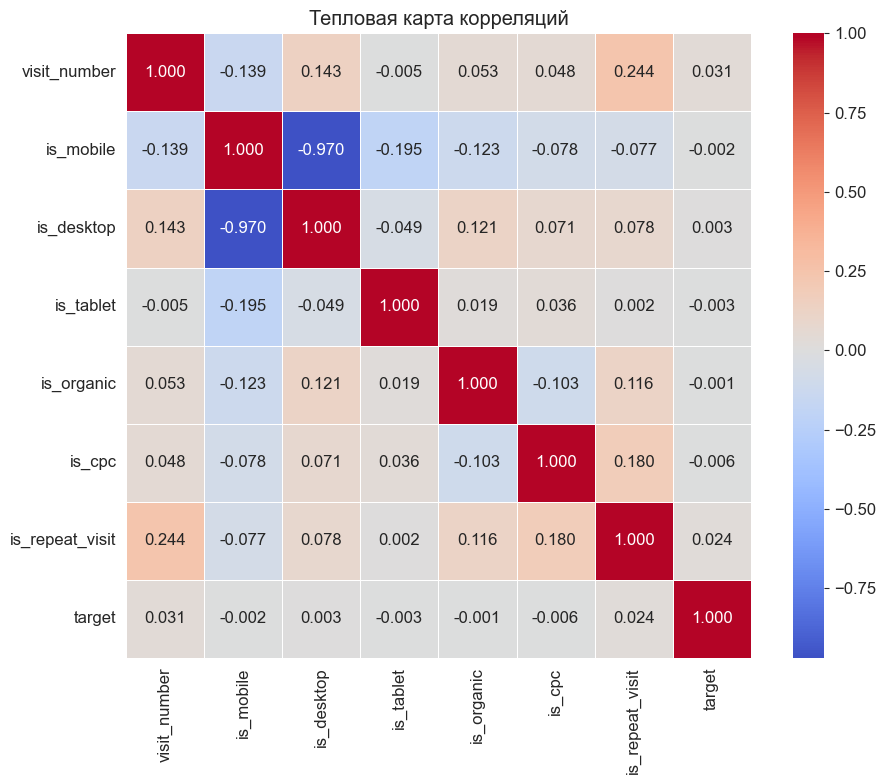

Корреляции с целевой переменной:
target             1.000000
visit_number       0.030947
is_repeat_visit    0.024003
is_desktop         0.003004
is_organic        -0.000620
is_mobile         -0.002309
is_tablet         -0.002630
is_cpc            -0.005845


In [9]:
# Тепловая карта корреляций
df_corr = df.copy()
df_corr['is_mobile']  = (df_corr['device_category'] == 'mobile').astype(int)
df_corr['is_desktop'] = (df_corr['device_category'] == 'desktop').astype(int)
df_corr['is_tablet']  = (df_corr['device_category'] == 'tablet').astype(int)
df_corr['is_organic'] = df_corr['utm_medium'].str.contains('organic', na=False).astype(int)
df_corr['is_cpc']     = df_corr['utm_medium'].str.contains('cpc', na=False).astype(int)
df_corr['is_repeat_visit'] = (df_corr['visit_number'] > 1).astype(int)

num_cols = ['visit_number', 'is_mobile', 'is_desktop', 'is_tablet',
            'is_organic', 'is_cpc', 'is_repeat_visit', 'target']

corr = df_corr[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

print('Корреляции с целевой переменной:')
print(corr['target'].sort_values(ascending=False).to_string())

**Вывод:** линейные корреляции с таргетом слабые (максимум 0.031 у `visit_number`). Это типично для задач с дисбалансом классов - линейные методы не улавливают нелинейные зависимости. Важно отметить мультиколлинеарность `is_mobile` и `is_desktop` (-0.97): в модели будем использовать `device_category` как единый категориальный признак.

## 3. Модель машинного обучения

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb

# Feature Engineering
df['month']           = df['visit_date'].dt.month
df['day_of_week']     = df['visit_date'].dt.dayofweek
df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
df['visit_time']      = pd.to_numeric(df['visit_time'], errors='coerce').fillna(0)
df['hour']            = (df['visit_time'] // 3600).astype(int).clip(0, 23)
df['is_work_hours']   = df['hour'].between(9, 18).astype(int)
df['is_first_visit']  = (df['visit_number'] == 1).astype(int)
df['is_repeat_visit'] = (df['visit_number'] > 1).astype(int)
df['visit_number_log']= np.log1p(df['visit_number'])
df['is_cpa']          = (df['utm_medium'] == 'cpa').astype(int)
df['is_smm']          = (df['utm_medium'] == 'smm').astype(int)
df['is_referral']     = (df['utm_medium'] == 'referral').astype(int)
df['is_organic']      = (df['utm_medium'] == 'organic').astype(int)
df['is_cpc']          = (df['utm_medium'] == 'cpc').astype(int)
df['is_push']         = (df['utm_medium'] == 'push').astype(int)
df['is_desktop']      = (df['device_category'] == 'desktop').astype(int)
df['is_mobile']       = (df['device_category'] == 'mobile').astype(int)
df['is_moscow']       = df['geo_city'].str.lower().str.contains('moscow|moskva', na=False).astype(int)
df['utm_medium_conv'] = df['utm_medium'].map(df.groupby('utm_medium')['target'].mean())
df['utm_source_conv'] = df['utm_source'].map(df.groupby('utm_source')['target'].mean())
df['city_conv']       = df['geo_city'].map(df.groupby('geo_city')['target'].mean())

In [11]:
feature_cols = [
    'visit_number', 'visit_number_log', 'month', 'day_of_week', 'hour',
    'is_first_visit', 'is_repeat_visit', 'is_desktop', 'is_mobile',
    'is_cpa', 'is_smm', 'is_referral', 'is_organic', 'is_cpc', 'is_push',
    'is_weekend', 'is_work_hours', 'is_moscow',
    'utm_medium_conv', 'utm_source_conv', 'city_conv',
]

X = df[feature_cols].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1488033, 21), Test: (372009, 21)


In [12]:
# Логистическая регрессия (baseline)
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

# LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)

print(f'Логистическая регрессия ROC-AUC: {lr_auc:.4f}')
print(f'Random Forest          ROC-AUC: {rf_auc:.4f}')
print(f'LightGBM               ROC-AUC: {lgbm_auc:.4f}')
print(f'Целевой показатель     ROC-AUC: >= 0.65')

c:\Users\Никита\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Логистическая регрессия ROC-AUC: 0.6734
Random Forest          ROC-AUC: 0.7072
LightGBM               ROC-AUC: 0.7191
Целевой показатель     ROC-AUC: >= 0.65


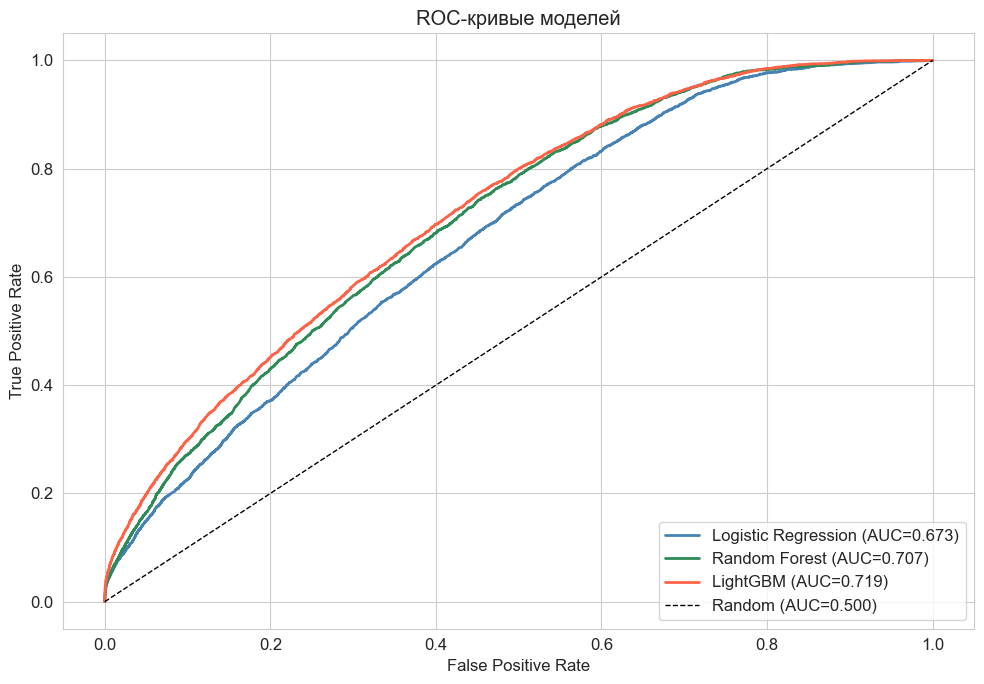

In [13]:
# ROC-кривые
fig, ax = plt.subplots(figsize=(10, 7))
for proba, name, color in [
    (lr_proba,   f'Logistic Regression (AUC={lr_auc:.3f})',   'steelblue'),
    (rf_proba,   f'Random Forest (AUC={rf_auc:.3f})',         'seagreen'),
    (lgbm_proba, f'LightGBM (AUC={lgbm_auc:.3f})',           'tomato'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=name, lw=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые моделей')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Вывод:** все три модели превышают целевой показатель ROC-AUC > 0.65. LightGBM показывает лучший результат (0.719) и лидирует на всём диапазоне FPR. Это объясняется тем, что градиентный бустинг лучше улавливает нелинейные зависимости в данных по сравнению с логистической регрессией.

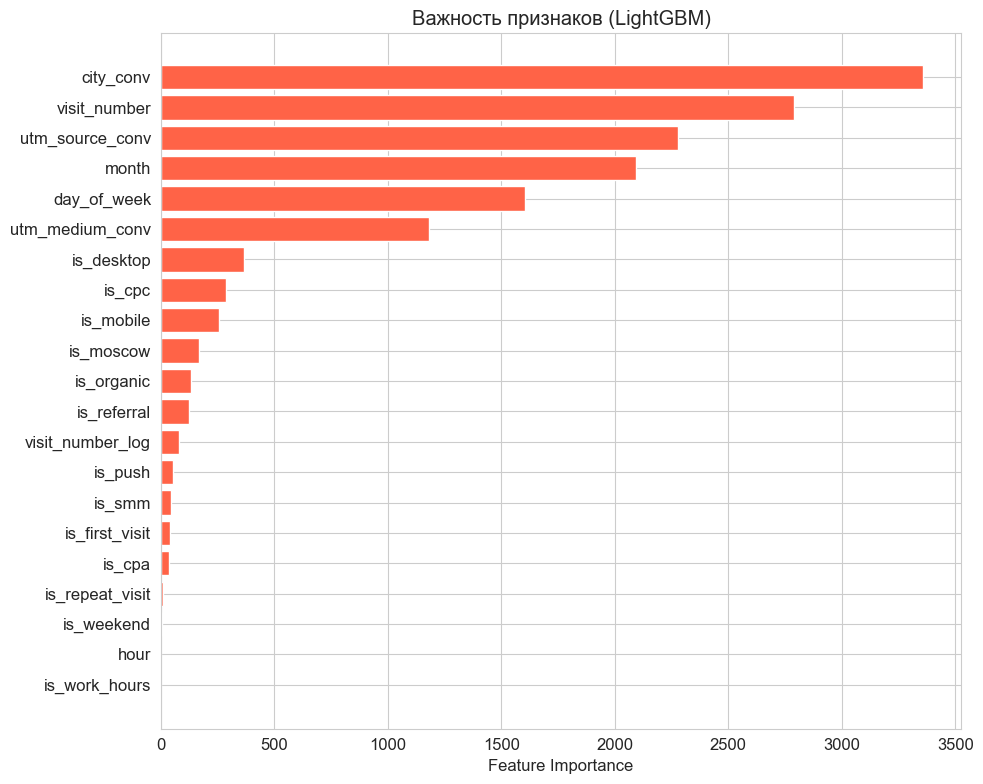

Топ-10 признаков:
        feature  importance
      city_conv        3358
   visit_number        2790
utm_source_conv        2276
          month        2092
    day_of_week        1604
utm_medium_conv        1183
     is_desktop         368
         is_cpc         287
      is_mobile         255
      is_moscow         167


In [14]:
# Важность признаков LightGBM
lgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(lgb_imp['feature'], lgb_imp['importance'], color='tomato')
ax.set_title('Важность признаков (LightGBM)')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Топ-10 признаков:')
print(lgb_imp.head(10).to_string(index=False))

**Интерпретация признаков:**

- `visit_number` — повторные пользователи конвертируют в 2 раза лучше первичных (пик на 4-5 визитах)
- `utm_source_conv` — канал привлечения несёт ключевую информацию о качестве трафика
- `month` и `day_of_week` — сезонность и день недели влияют на конверсию
- `utm_medium_conv` — тип привлечения: smm (12.95%), cpa (1.64%) конвертируют лучше cpc (0.80%)
- `is_desktop` — десктоп-пользователи конвертируют лучше мобильных(0.96% vs 0.89%)

## 4. Выводы

**Результаты моделирования:**
- Лучшая модель: LightGBM с ROC-AUC = 0.719 (целевой показатель > 0.65 достигнут)
- Все три модели превысили baseline

**Ключевые инсайты для бизнеса:**
1. Канал привлечения — главный фактор конверсии. SMM-трафик конвертирует в несколько раз лучше blogger_channel
2. Повторные пользователи ценнее новых: конверсия на 4-5 визите вдвое выше первичного
3. Ноябрь — лучший месяц для конверсий, стоит усилить рекламу в этот период
4. Десктоп-аудитория более склонна к целевым действиям — важно оптимизировать десктоп-версию сайта
5. География важна: Домодедово, Нальчик, Владикавказ — высококонверсионные города

**Модель позволяет:**
- Оценивать эффективность каналов привлечения в реальном времени
- Адаптировать рекламные кампании под высококонверсионные сегменты
- Персонализировать UX для пользователей с высокой вероятностью конверсии